In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_excel('Blinkit_Sales_Data.xlsx')

# 1. Basic Understanding of Data

In [23]:
df.sample(5)

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
7799,FDR32,6.78,Regular,0.000000,Fruits and Vegetables,227.4694,OUT046,1997,Small,Tier 1,Supermarket Type1,3197.1716
8081,FDB49,8.30,Regular,0.030274,Baking Goods,98.5384,OUT018,2009,Medium,Tier 3,Supermarket Type2,1872.2296
2560,DRQ35,9.30,Low Fat,0.042256,Hard Drinks,124.4388,OUT013,1987,High,Tier 3,Supermarket Type1,1609.9044
1471,DRO35,13.85,Low Fat,0.034640,Hard Drinks,116.1492,OUT045,2002,Medium,Tier 2,Supermarket Type1,1274.3412
721,FDA03,12.60,Regular,0.045244,Dairy,146.8102,OUT027,1985,Medium,Tier 3,Supermarket Type3,3499.4448


In [8]:
df.shape

(8523, 12)

In [10]:
df.columns

Index(['Item_Identifier', 'Item_Weight', 'Item_Fat_Content', 'Item_Visibility',
       'Item_Type', 'Item_MRP', 'Outlet_Identifier',
       'Outlet_Establishment_Year', 'Outlet_Size', 'Outlet_Location_Type',
       'Outlet_Type', 'Item_Outlet_Sales'],
      dtype='object')

In [24]:
df.describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,8523.00000,8523.000000,8523.000000,8523.000000,8523.000000
mean,12.81342,0.066132,140.992782,1997.831867,2181.288914
std,4.22724,0.051598,62.275067,8.371760,1706.499616
min,4.55500,0.000000,31.290000,1985.000000,33.290000
25%,9.31000,0.026989,93.826500,1987.000000,834.247400
50%,12.60000,0.053931,143.012800,1999.000000,1794.331000
75%,16.00000,0.094585,185.643700,2004.000000,3101.296400
max,21.35000,0.328391,266.888400,2009.000000,13086.964800


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [13]:
df.isnull().sum()

Item_Identifier                 0
Item_Weight                  1463
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64

# 2. Data Cleaning

In [18]:
# Handling Missing Values - (Item_Weight Numerical Column)

# Fill missing values in Item_Weight using the median.
df['Item_Weight'] = df['Item_Weight'].fillna(df['Item_Weight'].median())

# Check remaining missing values
print("Missing values in Item_Weight:", df['Item_Weight'].isnull().sum())

Missing values in Item_Weight: 0


In [19]:
# Handle Outlet_Size - (categorical Column)

# Fill missing values in Outlet_Size using the mode 
df['Outlet_Size'] = df['Outlet_Size'].fillna(df['Outlet_Size'].mode()[0])

# Check missing values
print("Missing values in Outlet_Size:", df['Outlet_Size'].isnull().sum())

Missing values in Outlet_Size: 0


In [21]:
df.isnull().sum()

Item_Identifier              0
Item_Weight                  0
Item_Fat_Content             0
Item_Visibility              0
Item_Type                    0
Item_MRP                     0
Outlet_Identifier            0
Outlet_Establishment_Year    0
Outlet_Size                  0
Outlet_Location_Type         0
Outlet_Type                  0
Item_Outlet_Sales            0
dtype: int64

# 3. Exploratory Data Analysis (EDA)

i> Distribution of Sales (Histogram)

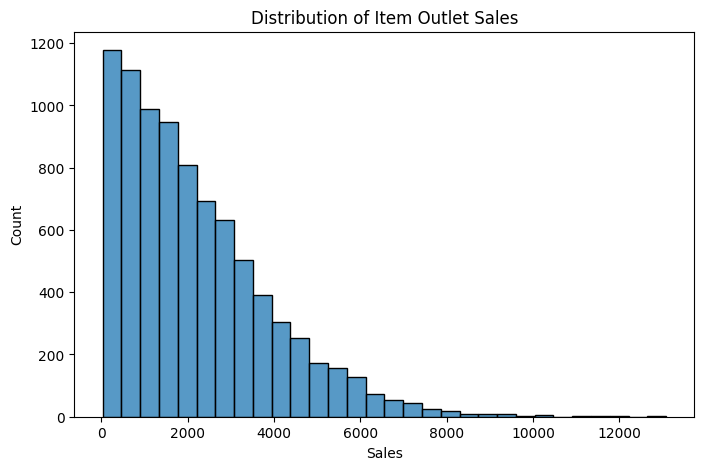

In [37]:
# Histogram of Item_Outlet_Sales
plt.figure(figsize=(8,5))
sns.histplot(df['Item_Outlet_Sales'], bins=30, kde=True)
plt.title("Distribution of Item Outlet Sales")
plt.xlabel("Sales")
plt.ylabel("Count")
plt.show()

ii> Count of Item Types (Bar Chart)

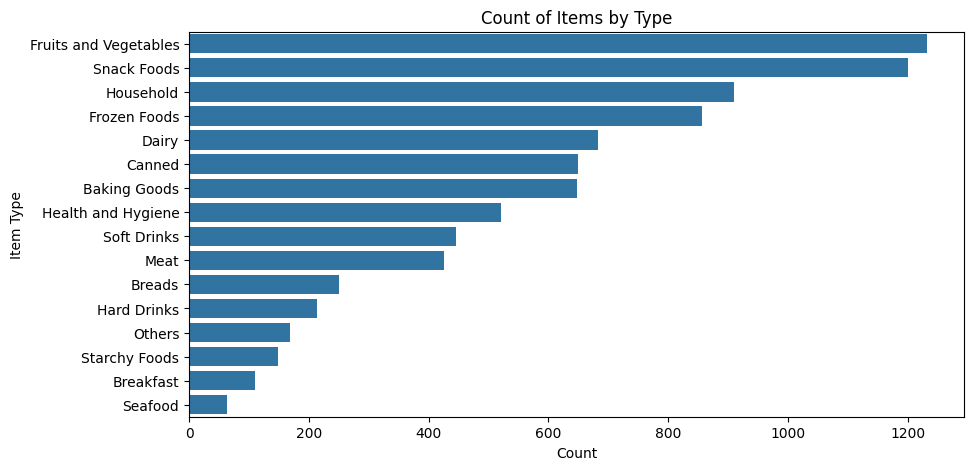

In [40]:
# Count of Item Types
plt.figure(figsize=(10,5))
sns.countplot(y='Item_Type', data=df, order=df['Item_Type'].value_counts().index)
plt.title("Count of Items by Type")
plt.xlabel("Count")
plt.ylabel("Item Type")
plt.show()

iii> Relationship between Price and Sales (Scatter Plot)

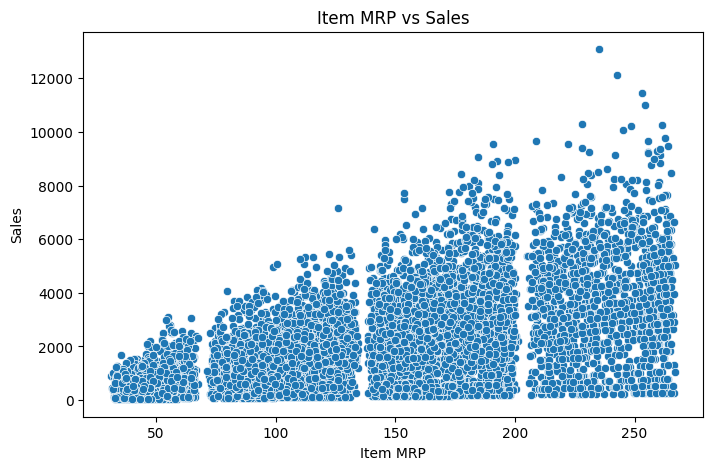

In [41]:
# Scatter plot of Item MRP vs Sales
plt.figure(figsize=(8,5))
sns.scatterplot(x='Item_MRP', y='Item_Outlet_Sales', data=df)
plt.title("Item MRP vs Sales")
plt.xlabel("Item MRP")
plt.ylabel("Sales")
plt.show()

iv> Sales by Outlet Type (Bar Plot)

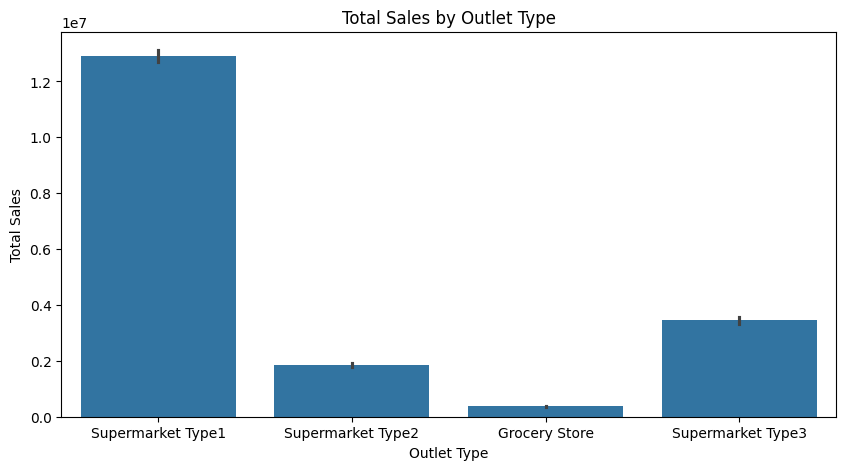

In [45]:
# Total Sales by Outlet Type
plt.figure(figsize=(10,5))
sns.barplot(x='Outlet_Type', y='Item_Outlet_Sales', data=df, estimator=sum)
plt.title("Total Sales by Outlet Type")
plt.xlabel("Outlet Type")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.show()

v> Correlation Heatmap

Text(0.5, 1.0, 'Correlation Heatmap')

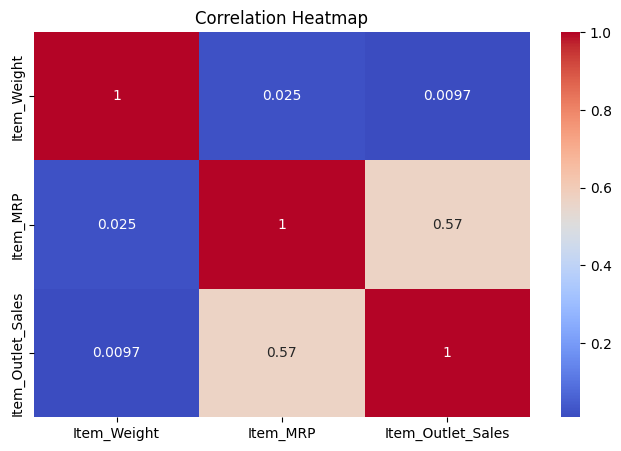

In [46]:
# Correlation heatmap for numeric columns
plt.figure(figsize=(8,5))
sns.heatmap(df[['Item_Weight','Item_MRP','Item_Outlet_Sales']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")